In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

print("All imports successful!")

All imports successful!


In [3]:
df = pd.read_csv('../data/resume_data.csv')

# Fix the BOM character in the column name
df.rename(columns={'\ufeffjob_position_name': 'job_position_name'}, inplace=True)

print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print()
print("Column names:")
for col in df.columns.tolist():
    print(f"  - {col}")

Dataset shape: (9544, 35)
Rows: 9544, Columns: 35

Column names:
  - address
  - career_objective
  - skills
  - educational_institution_name
  - degree_names
  - passing_years
  - educational_results
  - result_types
  - major_field_of_studies
  - professional_company_names
  - company_urls
  - start_dates
  - end_dates
  - related_skils_in_job
  - positions
  - locations
  - responsibilities
  - extra_curricular_activity_types
  - extra_curricular_organization_names
  - extra_curricular_organization_links
  - role_positions
  - languages
  - proficiency_levels
  - certification_providers
  - certification_skills
  - online_links
  - issue_dates
  - expiry_dates
  - job_position_name
  - educationaL_requirements
  - experiencere_requirement
  - age_requirement
  - responsibilities.1
  - skills_required
  - matched_score


In [3]:
# Calculate missing values percentage per column
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_percent': missing_pct
}).sort_values('missing_percent', ascending=False)

print(missing_df)

                                     missing_count  missing_percent
languages                                     8844        92.665549
proficiency_levels                            8844        92.665549
address                                       8760        91.785415
issue_dates                                   7536        78.960604
certification_skills                          7536        78.960604
certification_providers                       7536        78.960604
expiry_dates                                  7536        78.960604
online_links                                  7536        78.960604
extra_curricular_activity_types               6118        64.103101
extra_curricular_organization_links           6118        64.103101
extra_curricular_organization_names           6118        64.103101
role_positions                                6118        64.103101
career_objective                              4804        50.335289
age_requirement                               40

In [4]:
# Drop columns with more than 90% missing values
threshold = 0.9
cols_to_drop = [col for col in df.columns if df[col].isnull().mean() > threshold]

print("Columns being dropped:")
for col in cols_to_drop:
    print(f"  - {col} ({df[col].isnull().mean()*100:.1f}% null)")

df.drop(columns=cols_to_drop, inplace=True)
print(f"\nDataset shape after dropping: {df.shape}")

Columns being dropped:
  - address (91.8% null)
  - languages (92.7% null)
  - proficiency_levels (92.7% null)

Dataset shape after dropping: (9544, 32)


In [5]:
# Binary encode certification — 1 if exists, 0 if null
df['has_certification'] = df['certification_skills'].notnull().astype(int)

# Drop the original certification text columns and dates
cols_to_drop = ['certification_skills', 'certification_providers',
                'issue_dates', 'expiry_dates']

df.drop(columns=[col for col in cols_to_drop if col in df.columns], inplace=True)

print(df['has_certification'].value_counts())
print(f"Shape after: {df.shape}")

has_certification
0    7536
1    2008
Name: count, dtype: int64
Shape after: (9544, 29)


In [6]:
cols_to_drop = [
    'extra_curricular_activity_types',
    'extra_curricular_organization_names', 
    'extra_curricular_organization_links',
    'role_positions'
]

df.drop(columns=[col for col in cols_to_drop if col in df.columns], inplace=True)

print(f"Shape after dropping: {df.shape}")
print(f"Remaining columns: {df.columns.tolist()}")

Shape after dropping: (9544, 25)
Remaining columns: ['career_objective', 'skills', 'educational_institution_name', 'degree_names', 'passing_years', 'educational_results', 'result_types', 'major_field_of_studies', 'professional_company_names', 'company_urls', 'start_dates', 'end_dates', 'related_skils_in_job', 'positions', 'locations', 'responsibilities', 'online_links', 'job_position_name', 'educationaL_requirements', 'experiencere_requirement', 'age_requirement', 'responsibilities.1', 'skills_required', 'matched_score', 'has_certification']


In [8]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_percent': missing_pct
}).sort_values('missing_percent', ascending=False)

print(missing_df)

                              missing_count  missing_percent
online_links                           7536        78.960604
career_objective                       4804        50.335289
age_requirement                        4087        42.822716
skills_required                        1701        17.822716
experiencere_requirement               1364        14.291702
educational_institution_name             84         0.880134
degree_names                             84         0.880134
passing_years                            84         0.880134
educational_results                      84         0.880134
positions                                84         0.880134
professional_company_names               84         0.880134
result_types                             84         0.880134
major_field_of_studies                   84         0.880134
related_skils_in_job                     84         0.880134
company_urls                             84         0.880134
end_dates               

In [10]:
df

,career_objective,skills,educational_institution_name,degree_names,passing_years,educational_results,result_types,major_field_of_studies,professional_company_names,company_urls,start_dates,end_dates,related_skils_in_job,positions,locations,responsibilities,online_links,job_position_name,educationaL_requirements,experiencere_requirement,age_requirement,responsibilities.1,skills_required,matched_score,has_certification
0,Big data analytics working and database warehouse manager with robust experience in handling all...,"['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapreduce', 'Spark', 'Java', 'Machine Learning', 'Clou...","['The Amity School of Engineering & Technology (ASET), Noida']",['B.Tech'],['2019'],['N/A'],[None],['Electronics'],['Coca-COla'],[None],['Nov 2019'],['Till Date'],[['Big Data']],['Big Data Analyst'],['N/A'],Technical Support\nTroubleshooting\nCollaboration\nDocumentation\nSystem Monitoring\nSoftware De...,NaN,Senior Software Engineer,B.Sc in Computer Science & Engineering from a reputed university.,At least 1 year,NaN,Technical Support\nTroubleshooting\nCollaboration\nDocumentation\nSystem Monitoring\nSoftware De...,NaN,0.850000,0
1,Fresher looking to join as a data analyst and junior data scientist. Experienced in creating mea...,"['Data Analysis', 'Data Analytics', 'Business Analysis', 'R', 'SAS', 'PowerBi', 'Tableau', 'Data...","['Delhi University - Hansraj College', 'Delhi University - Hansraj College']","['B.Sc (Maths)', 'M.Sc (Science) (Statistics)']","['2015', '2018']","['N/A', 'N/A']","['N/A', 'N/A']","['Mathematics', 'Statistics']",['BIB Consultancy'],['N/A'],['Sep 2019'],['Till Date'],"[['Data Analysis', 'Business Analysis', 'Machine Learning']]",['Business Analyst'],['N/A'],Machine Learning Leadership\nCross-Functional Collaboration\nStrategy Development\nML/NLP Infras...,NaN,Machine Learning (ML) Engineer,M.Sc in Computer Science & Engineering or in any relevant discipline from a reputed University,At least 5 year(s),NaN,Machine Learning Leadership\nCross-Functional Collaboration\nStrategy Development\nML/NLP Infras...,NaN,0.750000,0
2,NaN,"['Software Development', 'Machine Learning', 'Deep Learning', 'Risk Assessment', 'Requirement Ga...","['Birla Institute of Technology (BIT), Ranchi']",['B.Tech'],['2018'],['N/A'],['N/A'],['Electronics/Telecommunication'],['Axis Bank Limited'],['N/A'],['June 2018'],['Till Date'],"[['Unified Payment Interface', 'Risk Prediction', 'Big Data', 'Spark', 'PySpark']]",['Software Developer (Machine Learning Engineer)'],['N/A'],"Trade Marketing Executive\nBrand Visibility, Sales Targets\nField Marketing, Campaigns, Product ...",NaN,"Executive/ Senior Executive- Trade Marketing, Hygiene Products",Master of Business Administration (MBA),At least 3 years,NaN,"Trade Marketing Executive\nBrand Visibility, Sales Targets\nField Marketing, Campaigns, Product ...",Brand Promotion\nCampaign Management\nField Supervision\nMerchandising\npromotional activities\n...,0.416667,0
3,"To obtain a position in a fast-paced business office environment, demanding a strong organizatio...","['accounts payables', 'accounts receivables', 'Accounts Payable', 'Accounts Receivable', 'admini...","['Martinez Adult Education, Business Training Center ï¼ City , State']",['Computer Applications Specialist Certificate Program'],['2008'],[None],[None],['Computer Applications'],"['Company Name ï¼ City , State', 'Company Name ï¼ City , State', 'Company Name ï¼ City , State',...","[None, None, None, None, None, None]","['January 2011', 'January 2008', 'January 2006', 'January 2004', 'January 2001', 'N/A']","['November 2015', 'January 2010', 'January 2008', 'January 2006', 'January 2004', None]","[['accounts receivables', 'banking', 'G/L Accounts', 'accounts payables', 'credit cards', 'recon...","['Accountant', 'Accounts Receivable Clerk', 'Mortgage Underwriter', 'Commercial Auto Underwriter...","['City, State', 'City, State', 'City, State', 'City, State', 'City, State', 'N/A']",Apparel Sourcing\nQuality Garment 

In [11]:
# Binary encode links — 1 if exists, 0 if null
df['has_links'] = df['online_links'].notnull().astype(int)

# Drop the original links text columns
cols_to_drop = ['online_links']

df.drop(columns=[col for col in cols_to_drop if col in df.columns], inplace=True)

print(df['has_links'].value_counts())
print(f"Shape after: {df.shape}")

has_links
0    7536
1    2008
Name: count, dtype: int64
Shape after: (9544, 25)


In [12]:
# Fill remaining text columns nulls with empty string
text_cols_to_fill = [
    'career_objective',
    'skills_required',
    'experiencere_requirement'
]

for col in text_cols_to_fill:
    if col in df.columns:
        df[col].fillna('', inplace=True)

print("Null counts after filling:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Null counts after filling:
career_objective                4804
skills                            56
educational_institution_name      84
degree_names                      84
passing_years                     84
educational_results               84
result_types                      84
major_field_of_studies            84
professional_company_names        84
company_urls                      84
start_dates                       84
end_dates                         84
related_skils_in_job              84
positions                         84
locations                         84
experiencere_requirement        1364
age_requirement                 4087
skills_required                 1701
dtype: int64


C:\Users\user\AppData\Local\Temp\ipykernel_17320\2415185737.py:10: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna('', inplace=True)


In [14]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_percent': missing_pct
}).sort_values('missing_percent', ascending=False)

print(missing_df)

                              missing_count  missing_percent
career_objective                       4804        50.335289
age_requirement                        4087        42.822716
skills_required                        1701        17.822716
experiencere_requirement               1364        14.291702
educational_institution_name             84         0.880134
major_field_of_studies                   84         0.880134
degree_names                             84         0.880134
passing_years                            84         0.880134
educational_results                      84         0.880134
locations                                84         0.880134
professional_company_names               84         0.880134
result_types                             84         0.880134
company_urls                             84         0.880134
positions                                84         0.880134
start_dates                              84         0.880134
end_dates               

In [15]:
print(df.columns.tolist())

['career_objective', 'skills', 'educational_institution_name', 'degree_names', 'passing_years', 'educational_results', 'result_types', 'major_field_of_studies', 'professional_company_names', 'company_urls', 'start_dates', 'end_dates', 'related_skils_in_job', 'positions', 'locations', 'responsibilities', 'job_position_name', 'educationaL_requirements', 'experiencere_requirement', 'age_requirement', 'responsibilities.1', 'skills_required', 'matched_score', 'has_certification', 'has_links']


In [16]:
print(df.isnull().sum()[df.isnull().sum() > 0])

career_objective                4804
skills                            56
educational_institution_name      84
degree_names                      84
passing_years                     84
educational_results               84
result_types                      84
major_field_of_studies            84
professional_company_names        84
company_urls                      84
start_dates                       84
end_dates                         84
related_skils_in_job              84
positions                         84
locations                         84
experiencere_requirement        1364
age_requirement                 4087
skills_required                 1701
dtype: int64


In [17]:
text_cols_to_fill = [
    'career_objective',
    'skills_required',
    'experiencere_requirement',
    'related_skils_in_job',
    'positions',
    'professional_company_names'
]

for col in text_cols_to_fill:
    if col in df.columns:
        df[col].fillna('', inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_17320\519163405.py:12: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna('', inplace=True)


In [18]:
print(df.isnull().sum()[df.isnull().sum() > 0])

career_objective                4804
skills                            56
educational_institution_name      84
degree_names                      84
passing_years                     84
educational_results               84
result_types                      84
major_field_of_studies            84
professional_company_names        84
company_urls                      84
start_dates                       84
end_dates                         84
related_skils_in_job              84
positions                         84
locations                         84
experiencere_requirement        1364
age_requirement                 4087
skills_required                 1701
dtype: int64


In [19]:
# Check exact null counts and column names side by side
for col in df.columns:
    nulls = df[col].isnull().sum()
    if nulls > 0:
        print(f"'{col}' : {nulls}")
    

'career_objective' : 4804
'skills' : 56
'educational_institution_name' : 84
'degree_names' : 84
'passing_years' : 84
'educational_results' : 84
'result_types' : 84
'major_field_of_studies' : 84
'professional_company_names' : 84
'company_urls' : 84
'start_dates' : 84
'end_dates' : 84
'related_skils_in_job' : 84
'positions' : 84
'locations' : 84
'experiencere_requirement' : 1364
'age_requirement' : 4087
'skills_required' : 1701


In [20]:
# Step 1 - Fill with empty string
text_cols_to_fill = [
    'career_objective',
    'skills_required',
    'experiencere_requirement',
    'related_skils_in_job',
    'positions',
    'professional_company_names'
]
for col in text_cols_to_fill:
    df[col] = df[col].fillna('')

# Step 2 - Drop rows with nulls in small-null columns
cols_drop_rows = [
    'skills',
    'educational_institution_name',
    'degree_names',
    'passing_years',
    'educational_results',
    'result_types',
    'major_field_of_studies',
    'start_dates',
    'end_dates',
    'locations'
]
rows_before = len(df)
df = df.dropna(subset=cols_drop_rows)
print(f"Rows dropped: {rows_before - len(df)}")

# Step 3 - Drop columns entirely
cols_to_drop = ['age_requirement', 'company_urls']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

# Step 4 - Verify
print(f"Final shape: {df.shape}")
print(f"Total remaining nulls: {df.isnull().sum().sum()}")

Rows dropped: 224
Final shape: (9320, 23)
Total remaining nulls: 0


In [21]:
print(df.isnull().sum()[df.isnull().sum() > 0])

Series([], dtype: int64)


In [22]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_percent': missing_pct
}).sort_values('missing_percent', ascending=False)

print(missing_df)

                              missing_count  missing_percent
career_objective                          0              0.0
skills                                    0              0.0
educational_institution_name              0              0.0
degree_names                              0              0.0
passing_years                             0              0.0
educational_results                       0              0.0
result_types                              0              0.0
major_field_of_studies                    0              0.0
professional_company_names                0              0.0
start_dates                               0              0.0
end_dates                                 0              0.0
related_skils_in_job                      0              0.0
positions                                 0              0.0
locations                                 0              0.0
responsibilities                          0              0.0
job_position_name       

In [24]:
print("educational_results:")
print(df['educational_results'].value_counts().head(10))
print()
print("result_types:")
print(df['result_types'].value_counts().head(10))
print()
print("locations:")
print(df['locations'].value_counts().head(10))

educational_results:
educational_results
['N/A']                         3584
['N/A', 'N/A']                  1600
[None]                           700
[None, None]                     692
['N/A', 'N/A', 'N/A']            292
[None, None, None]               252
['3.8']                           84
['N/A', 'N/A', 'N/A', 'N/A']      84
['3.84']                          56
['4.0', None, None]               56
Name: count, dtype: int64

result_types:
result_types
['N/A']                         3388
['N/A', 'N/A']                  1516
[None]                          1036
[None, None]                     944
['GPA']                          654
[None, None, None]               308
['N/A', 'N/A', 'N/A']            292
['GPA', 'GPA']                   280
['GPA', None]                    112
['N/A', 'N/A', 'N/A', 'N/A']     112
Name: count, dtype: int64

locations:
locations
['N/A']                                                                                             3164
['City, Stat

In [25]:
# Drop low quality columns
cols_to_drop = ['educational_results', 'result_types', 'locations']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

print(f"Shape after dropping: {df.shape}")
print(f"Remaining columns: {df.columns.tolist()}")

Shape after dropping: (9320, 20)
Remaining columns: ['career_objective', 'skills', 'educational_institution_name', 'degree_names', 'passing_years', 'major_field_of_studies', 'professional_company_names', 'start_dates', 'end_dates', 'related_skils_in_job', 'positions', 'responsibilities', 'job_position_name', 'educationaL_requirements', 'experiencere_requirement', 'responsibilities.1', 'skills_required', 'matched_score', 'has_certification', 'has_links']


In [26]:
df.to_csv('../data/resume_data_cleaned.csv', index=False)
print("Saved!")

Saved!


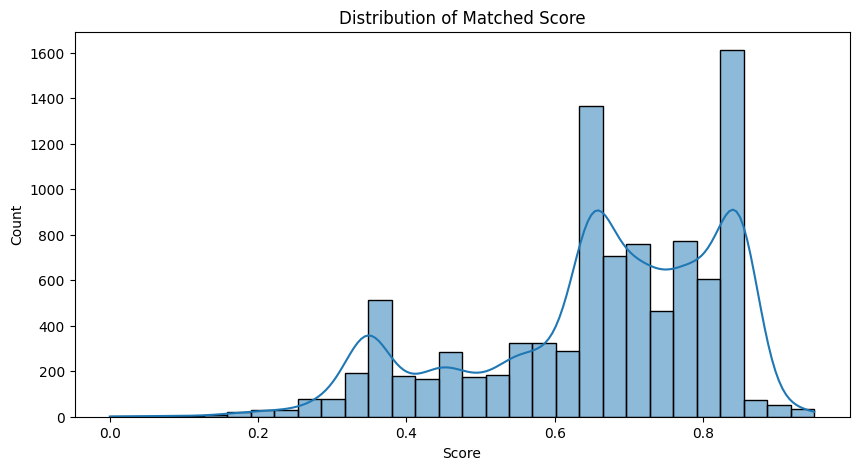

count    9320.000000
mean        0.661616
std         0.166654
min         0.000000
25%         0.583333
50%         0.683333
75%         0.793333
max         0.950000
Name: matched_score, dtype: float64


In [27]:
plt.figure(figsize=(10, 5))
sns.histplot(df['matched_score'], bins=30, kde=True)
plt.title('Distribution of Matched Score')
plt.xlabel('Score')
plt.ylabel('Count')
plt.show()

print(df['matched_score'].describe())

In [28]:
# Check numerical columns only
print("Numerical columns:")
print(df.select_dtypes(include=['number']).columns.tolist())

Numerical columns:
['matched_score', 'has_certification', 'has_links']


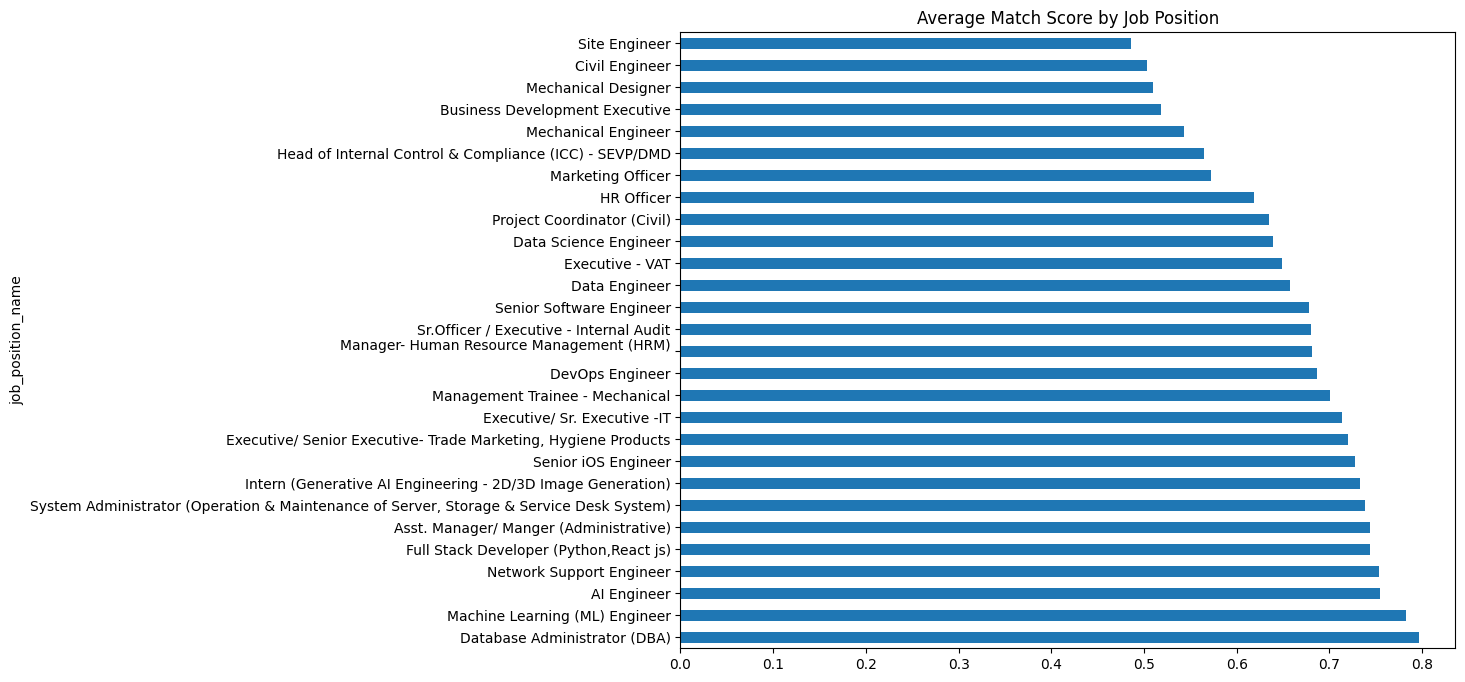

In [30]:
df.groupby('job_position_name')['matched_score'].mean().sort_values(ascending=False).plot(kind='barh', figsize=(10,8))
plt.title('Average Match Score by Job Position')
plt.show()

In [32]:
# Split skills into individual keywords
from collections import Counter

high_score = df[df['matched_score'] > 0.75]['skills'].str.cat(sep=',').lower()
low_score = df[df['matched_score'] < 0.50]['skills'].str.cat(sep=',').lower()

high_words = Counter(high_score.split(','))
low_words = Counter(low_score.split(','))

print("Top skills in HIGH scoring resumes:")
print(high_words.most_common(10))
print()
print("Top skills in LOW scoring resumes:")
print(low_words.most_common(10))

Top skills in HIGH scoring resumes:
[(" 'python'", 753), (" 'machine learning'", 650), (" 'excel'", 535), (" 'sql'", 472), (" 'documentation'", 438), (" 'java'", 429), (" 'sales'", 419), (" 'processes'", 413), (" 'c++'", 397), (" 'inventory'", 373)]

Top skills in LOW scoring resumes:
[(" 'machine learning'", 606), (" 'python'", 592), (" 'sql'", 359), (" 'deep learning'", 342), (" 'natural language processing'", 267), (" 'excel'", 249), (" 'data analysis'", 228), (" 'artificial intelligence'", 196), ("['machine learning'", 188), (" 'java'", 187)]


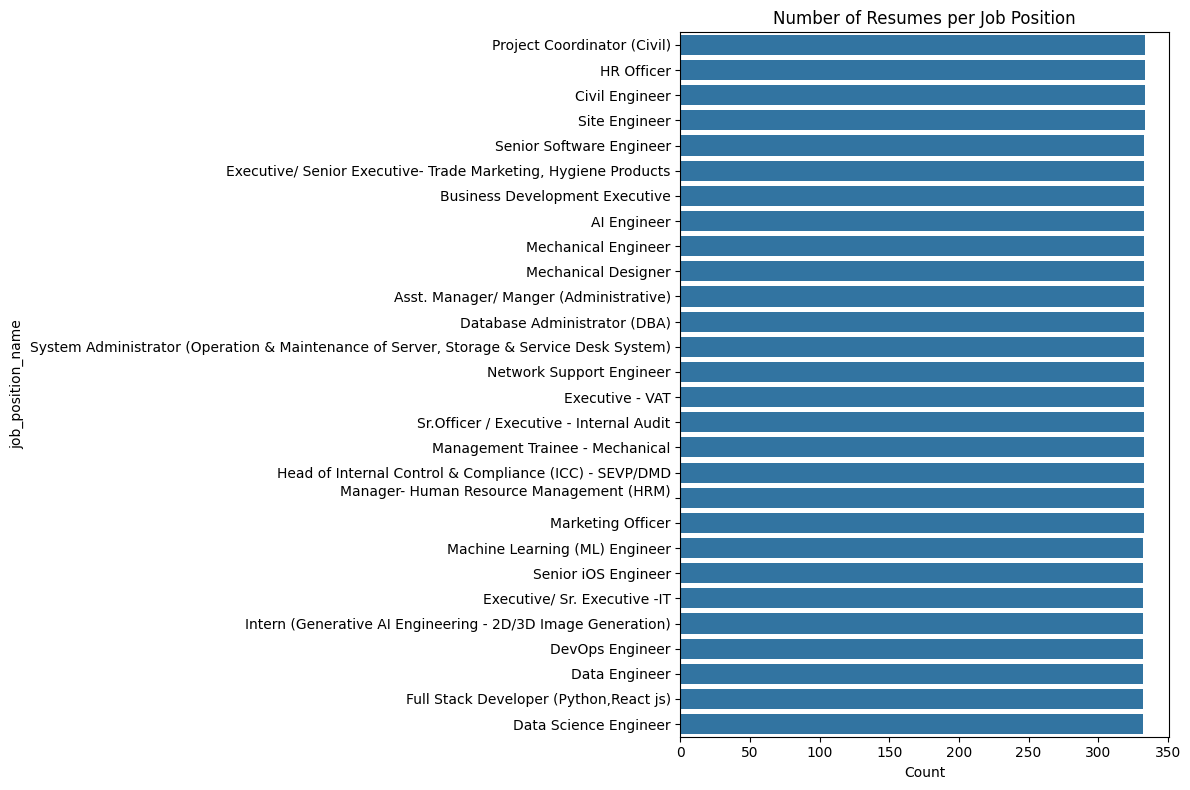

job_position_name
Project Coordinator (Civil)                                                                334
HR Officer                                                                                 334
Civil Engineer                                                                             334
Site Engineer                                                                              334
Senior Software Engineer                                                                   333
Executive/ Senior Executive- Trade Marketing, Hygiene Products                             333
Business Development Executive                                                             333
AI Engineer                                                                                333
Mechanical Engineer                                                                        333
Mechanical Designer                                                                        333
Asst. Manager/ Manger (Administr

In [33]:
# Goal 3 - Job position balance
plt.figure(figsize=(12, 8))
job_counts = df['job_position_name'].value_counts()
sns.barplot(x=job_counts.values, y=job_counts.index)
plt.title('Number of Resumes per Job Position')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

print(job_counts)

skills:
  avg: 365 chars | min: 2 | max: 3104

career_objective:
  avg: 112 chars | min: 0 | max: 1425

responsibilities:
  avg: 217 chars | min: 72 | max: 587

skills_required:
  avg: 59 chars | min: 0 | max: 163

experiencere_requirement:
  avg: 12 chars | min: 0 | max: 18



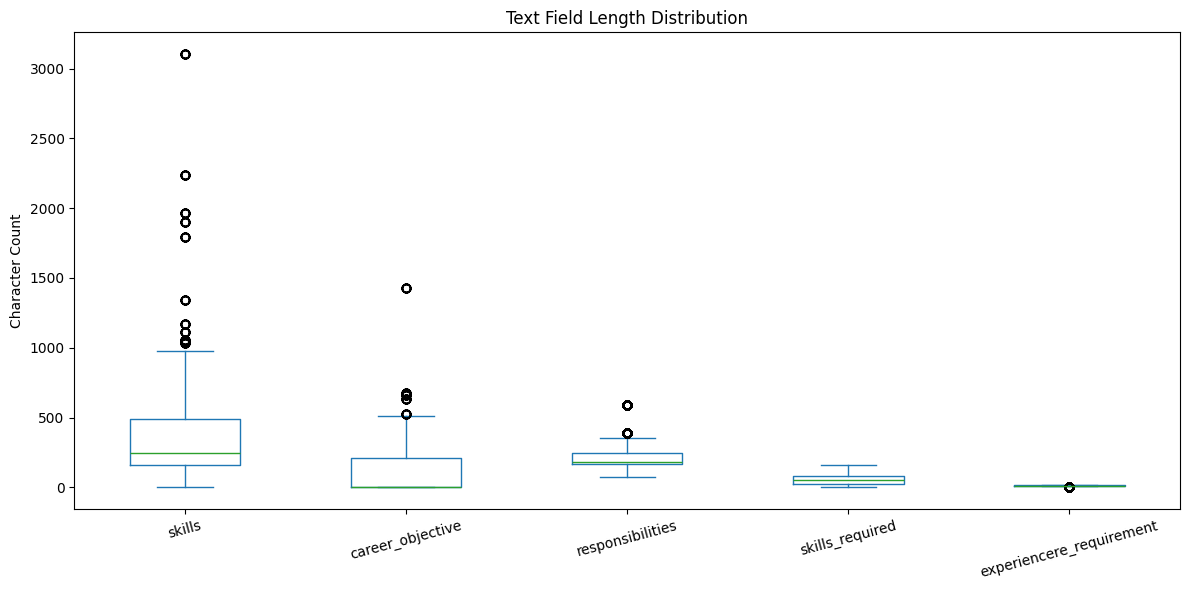

In [34]:
# Goal 4 - Text field lengths
text_cols = ['skills', 'career_objective', 'responsibilities', 
             'skills_required', 'experiencere_requirement']

for col in text_cols:
    lengths = df[col].astype(str).apply(len)
    print(f"{col}:")
    print(f"  avg: {lengths.mean():.0f} chars | min: {lengths.min()} | max: {lengths.max()}")
    print()

# Visualize
df_lengths = pd.DataFrame({col: df[col].astype(str).apply(len) for col in text_cols})
df_lengths.plot(kind='box', figsize=(12, 6))
plt.title('Text Field Length Distribution')
plt.ylabel('Character Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

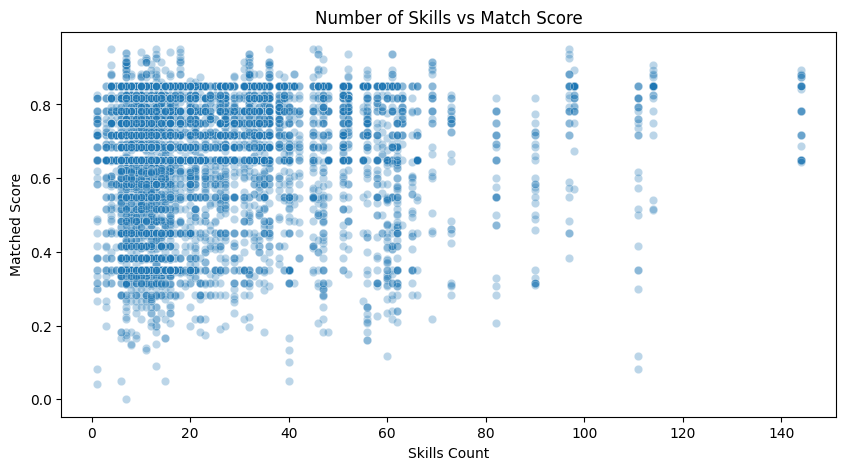

               skills_count  matched_score
skills_count       1.000000       0.108061
matched_score      0.108061       1.000000


In [35]:
# Goal 5 - Skills count vs score
df['skills_count'] = df['skills'].astype(str).apply(lambda x: len(x.split(',')))

plt.figure(figsize=(10, 5))
sns.scatterplot(x='skills_count', y='matched_score', data=df, alpha=0.3)
plt.title('Number of Skills vs Match Score')
plt.xlabel('Skills Count')
plt.ylabel('Matched Score')
plt.show()

print(df[['skills_count', 'matched_score']].corr())